# Scratch space to look at some of the cell cycling genes
February 9, 2024


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [22]:
def deconvolve_gene(gene_name):
    """
    Deconvolve a gene's gene expression and chromatin
    """
    from src.model import Model
    from cc_src.chromatin_model import ChromatinModel
    from cc_src.combined_chromatin_model import CombinedChromatinModel
    from src.config import load_yl_replicate1_rg1_alpha_vst_config, \
        load_yl_replicate2_rg1_alpha_vst_config, \
        load_combined_yl_alpha_vst_gene_expression_config

    # Load the config for each model
    ge_config = load_combined_yl_alpha_vst_gene_expression_config()
    config1 = load_yl_replicate1_rg1_alpha_vst_config()
    config2 = load_yl_replicate2_rg1_alpha_vst_config()

    print(f"Deconvolving {gene_name}, combined model")
    print(f"Deconvolving gene expression...", end="")
    ge_model = Model(ge_config, gene_name)
    ge_model.deconvolve_find_optimal_gamma()
    print("Done.")

    print(f"Deconvolving chromatin...", end="")
    combined_model = CombinedChromatinModel(config1, config2)
    combined_model.load_combined_mnase_gene(gene_name)
    combined_model.deconvolve_find_optimal_gamma()
    print("Done.")

    fig = combined_model.create_deconvolution_plots_abbreviated_flipped(ge_model)
    fig = combined_model.plot_raw_prediction(1)
    fig = combined_model.plot_raw_prediction(2)
    return combined_model

Deconvolving CLN3, combined model
Deconvolving gene expression...Done.
Deconvolving chromatin...Loading MNase reads for CLN3...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (16, 27)
Loading MNase reads for CLN3...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (15, 27)
Applying normalization using scaling matrix: output/mnase/rep2_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (15, 27)
Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 1.5989
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 1.6789, rate = 5.0
  ...   gm = 0.0050, rn = 1.8260, rate = 14.20, time = 00:00:38.

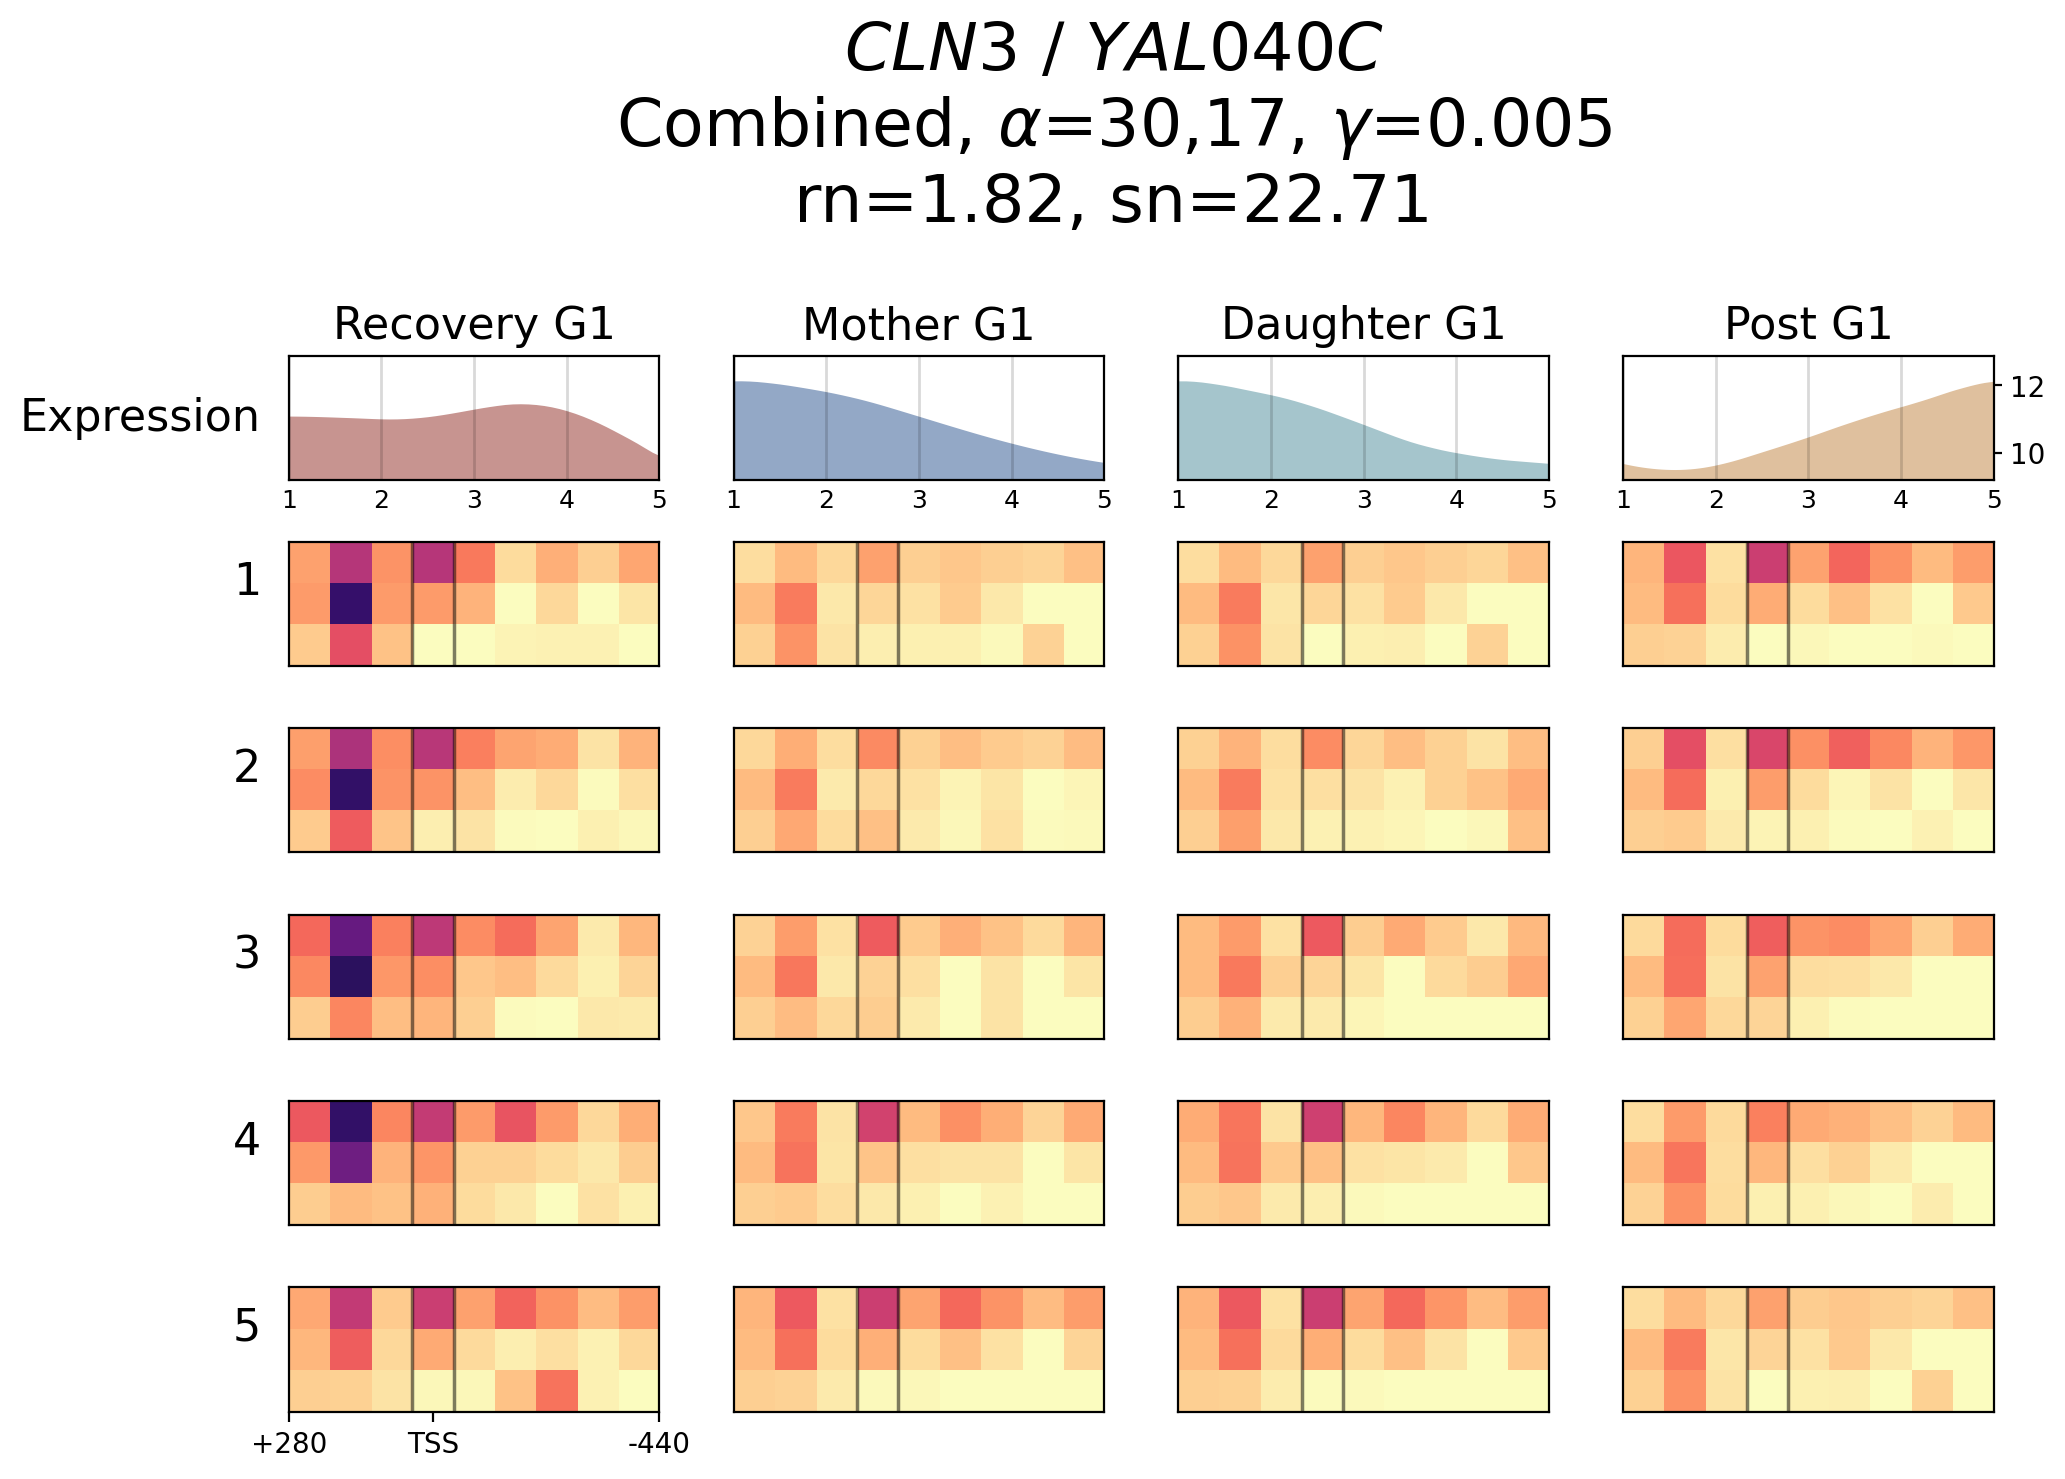

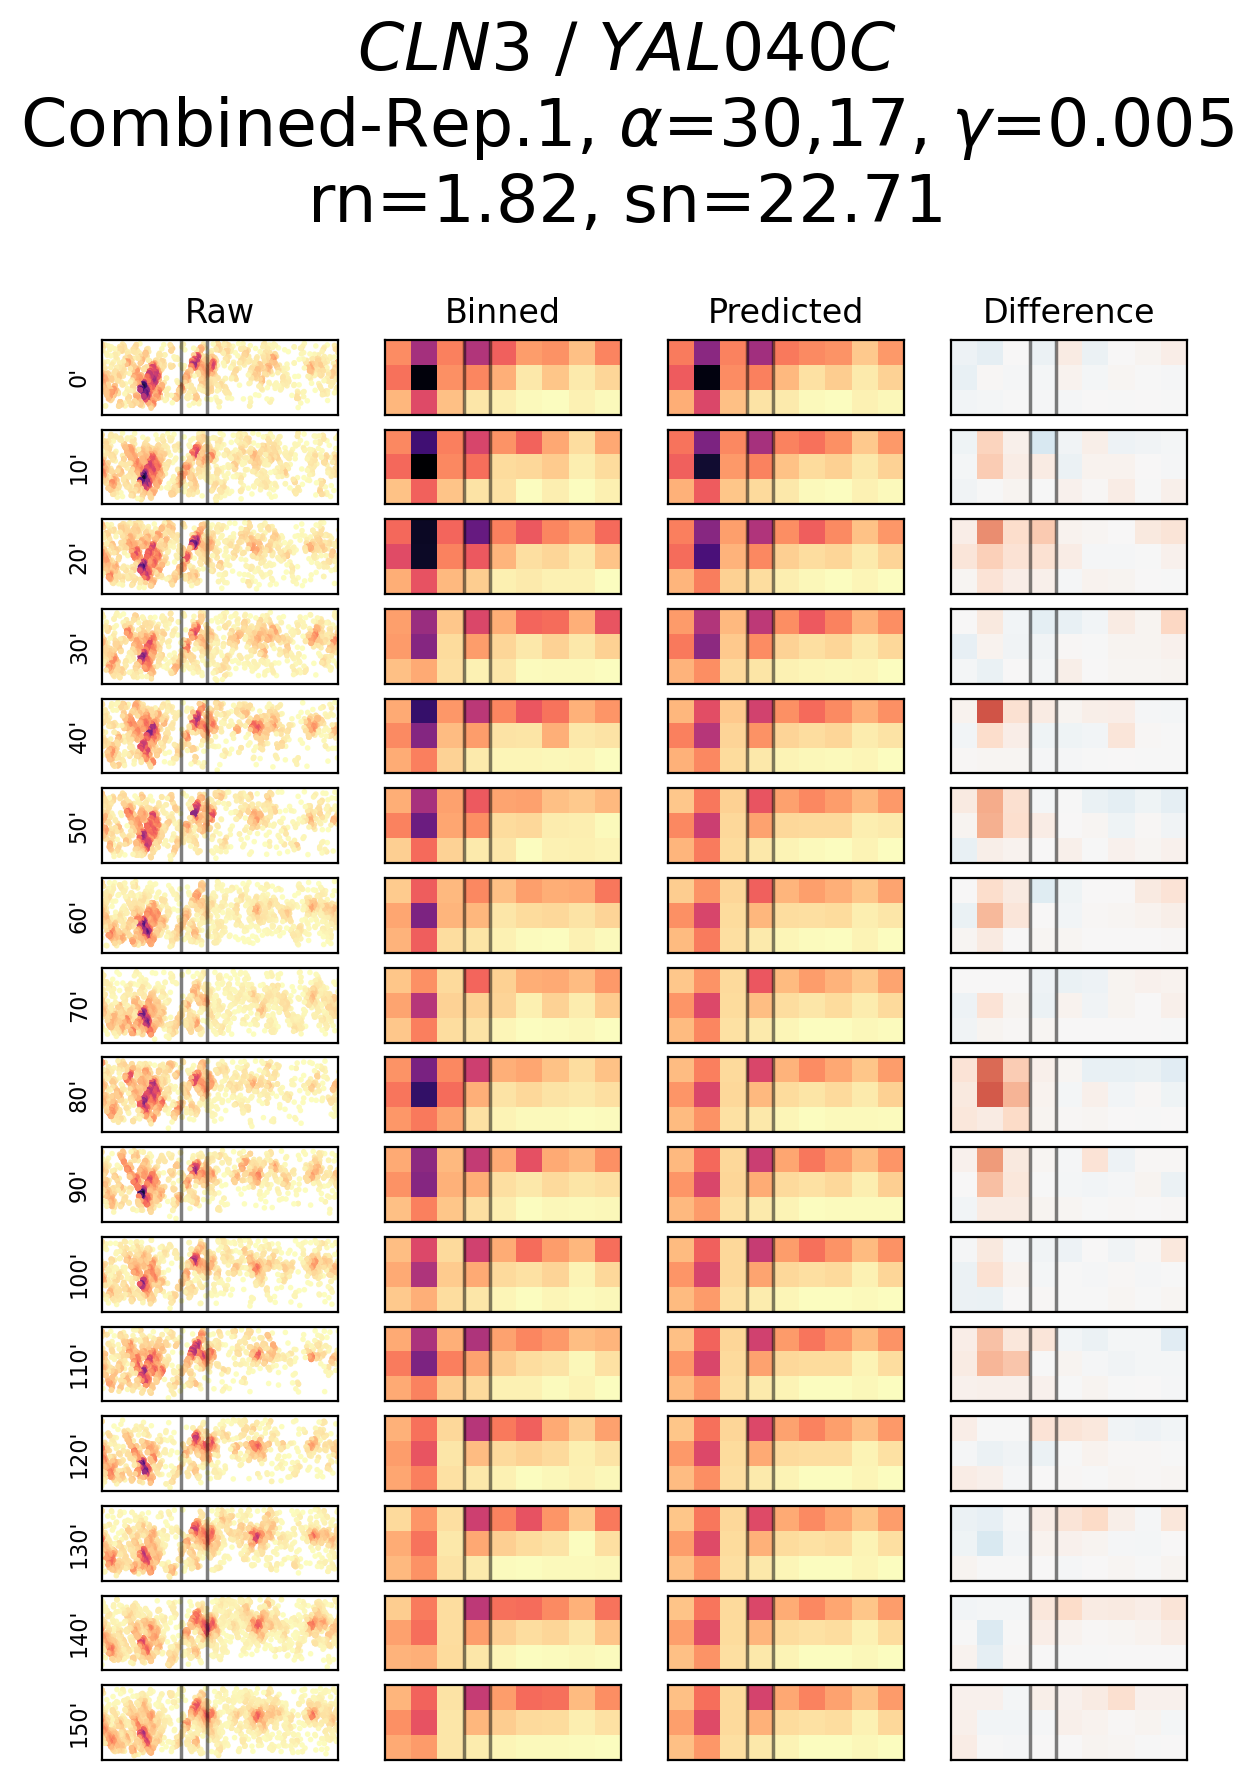

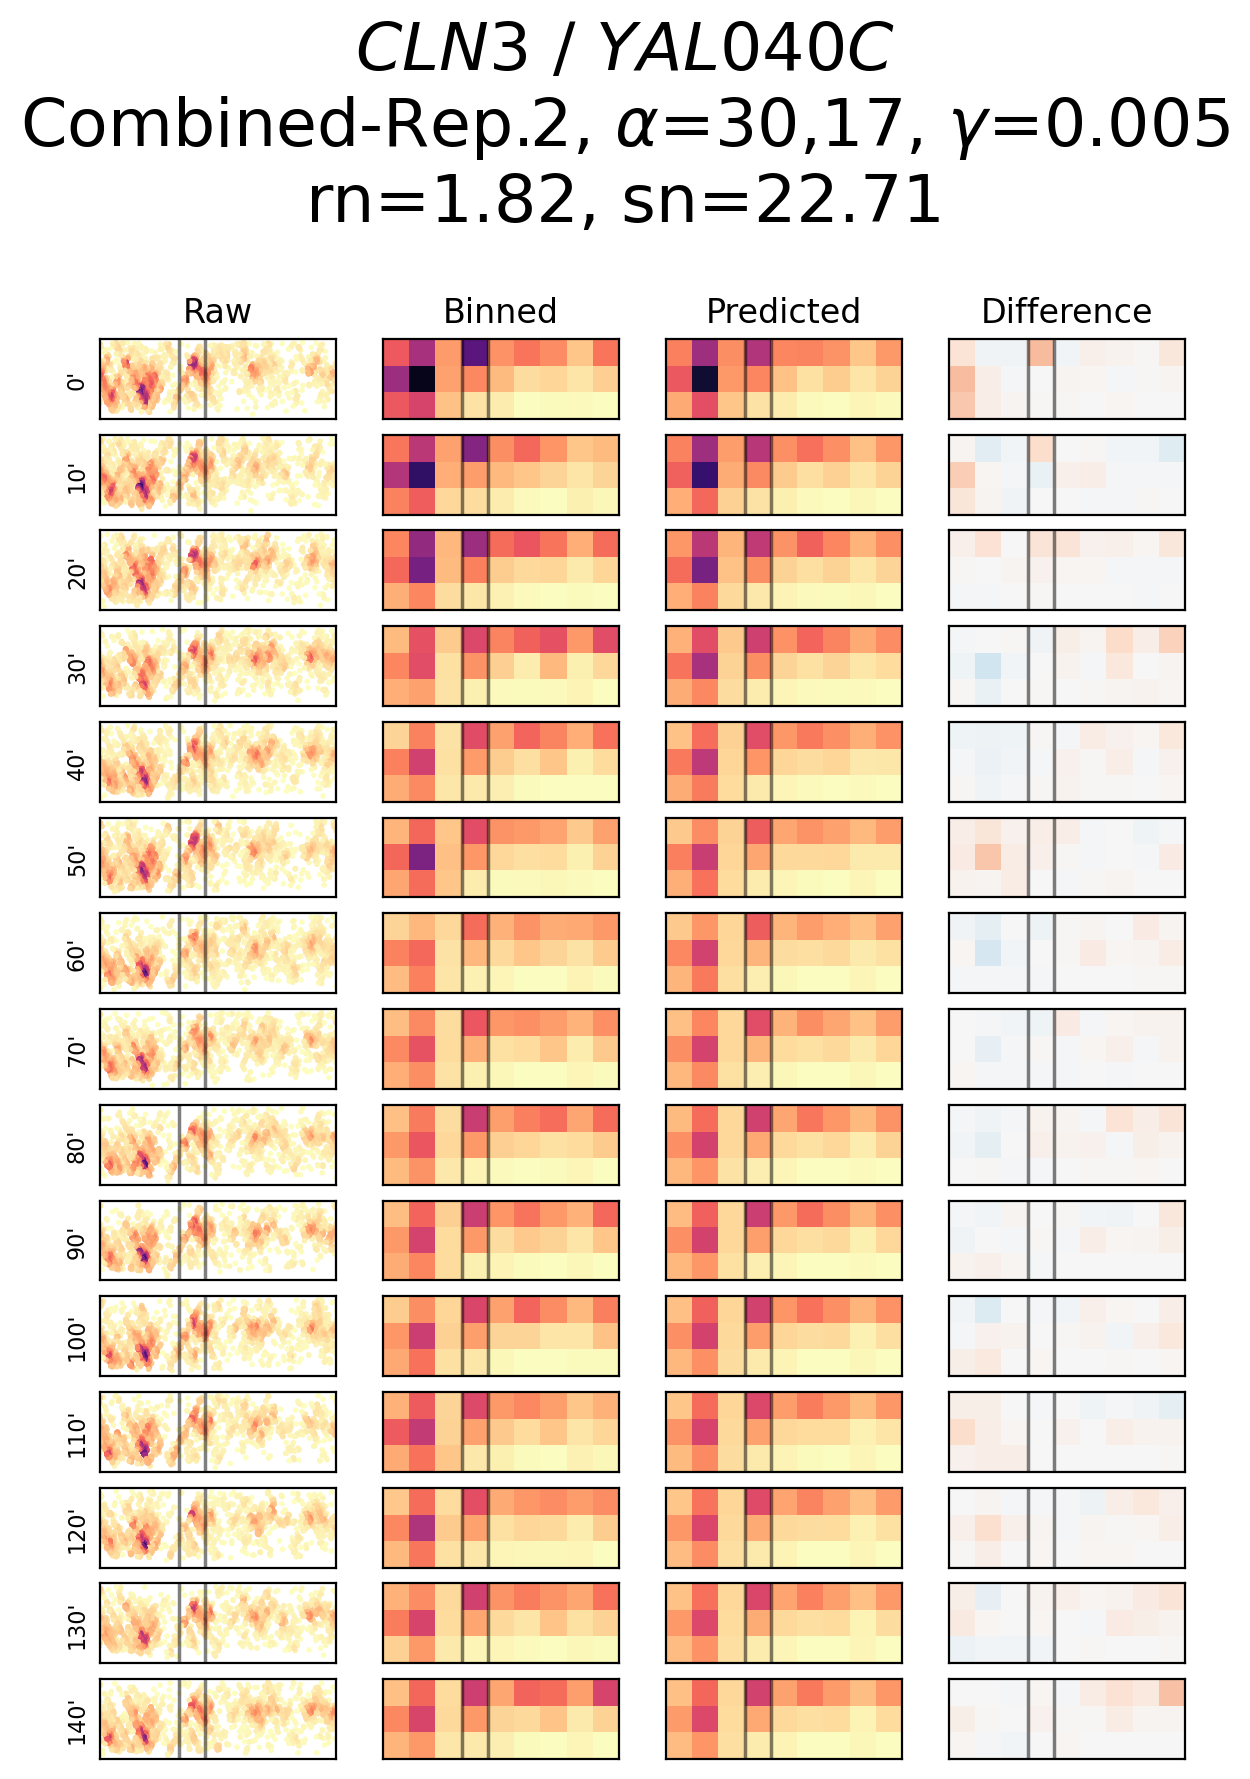

In [25]:
combined_model = deconvolve_gene('CLN3')

Deconvolving CLN1, combined model
Deconvolving gene expression...Done.
Deconvolving chromatin...Loading MNase reads for CLN1...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (16, 27)
Loading MNase reads for CLN1...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (15, 27)
Applying normalization using scaling matrix: output/mnase/rep2_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (15, 27)
Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 1.5828
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 1.6628, rate = 5.1
  ...   gm = 0.0050, rn = 1.8175, rate = 14.83, time = 00:00:39.

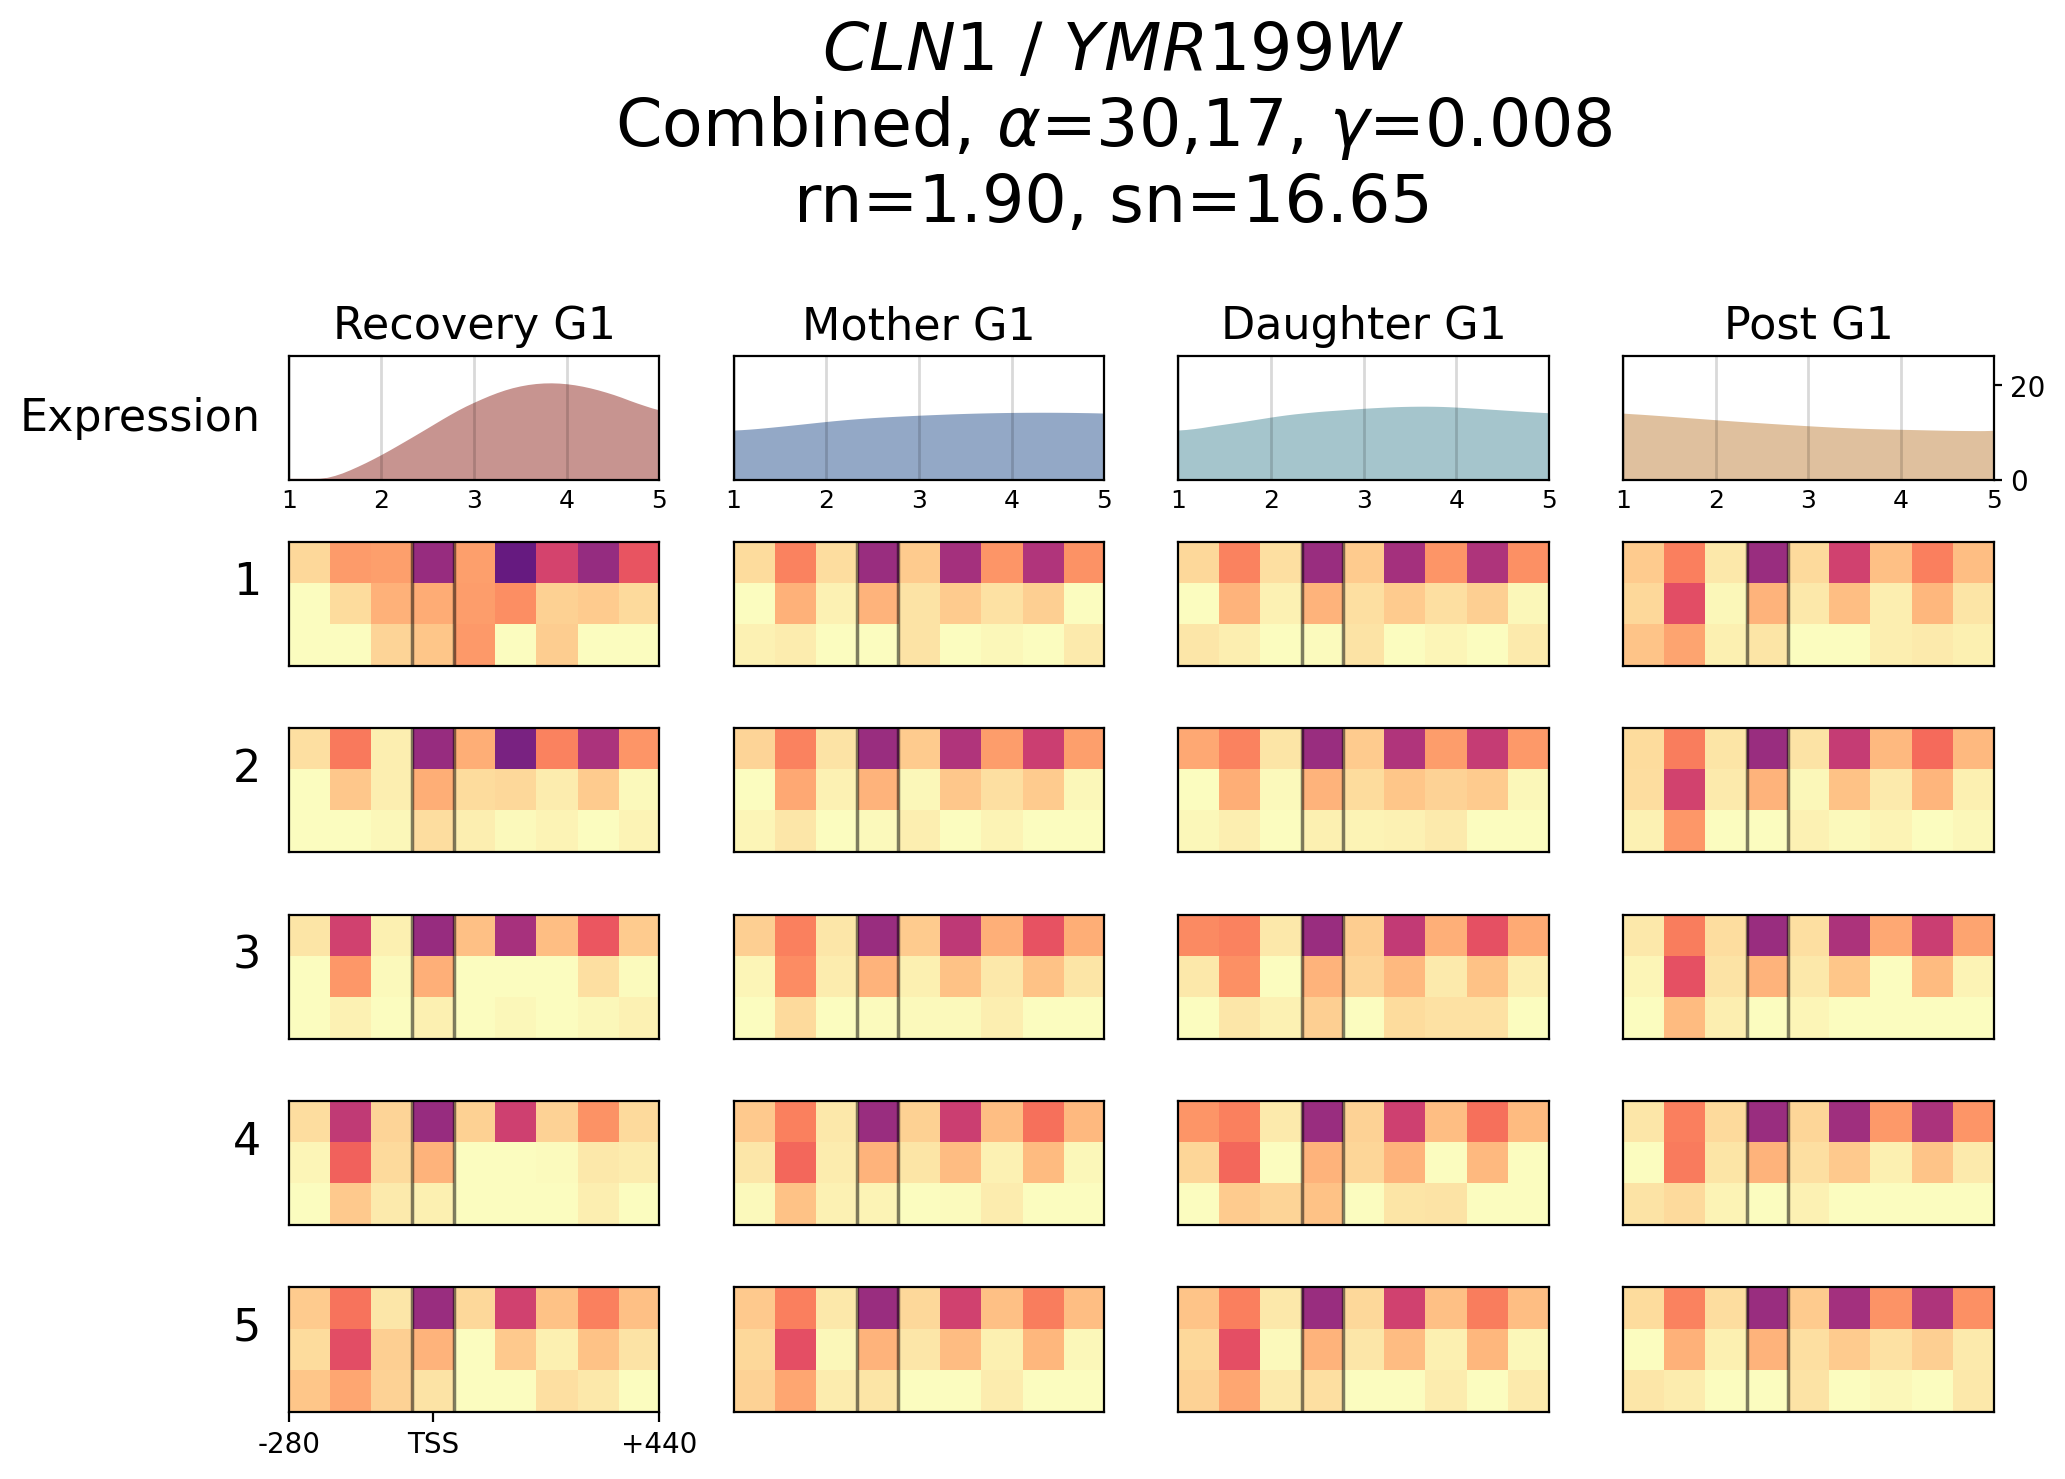

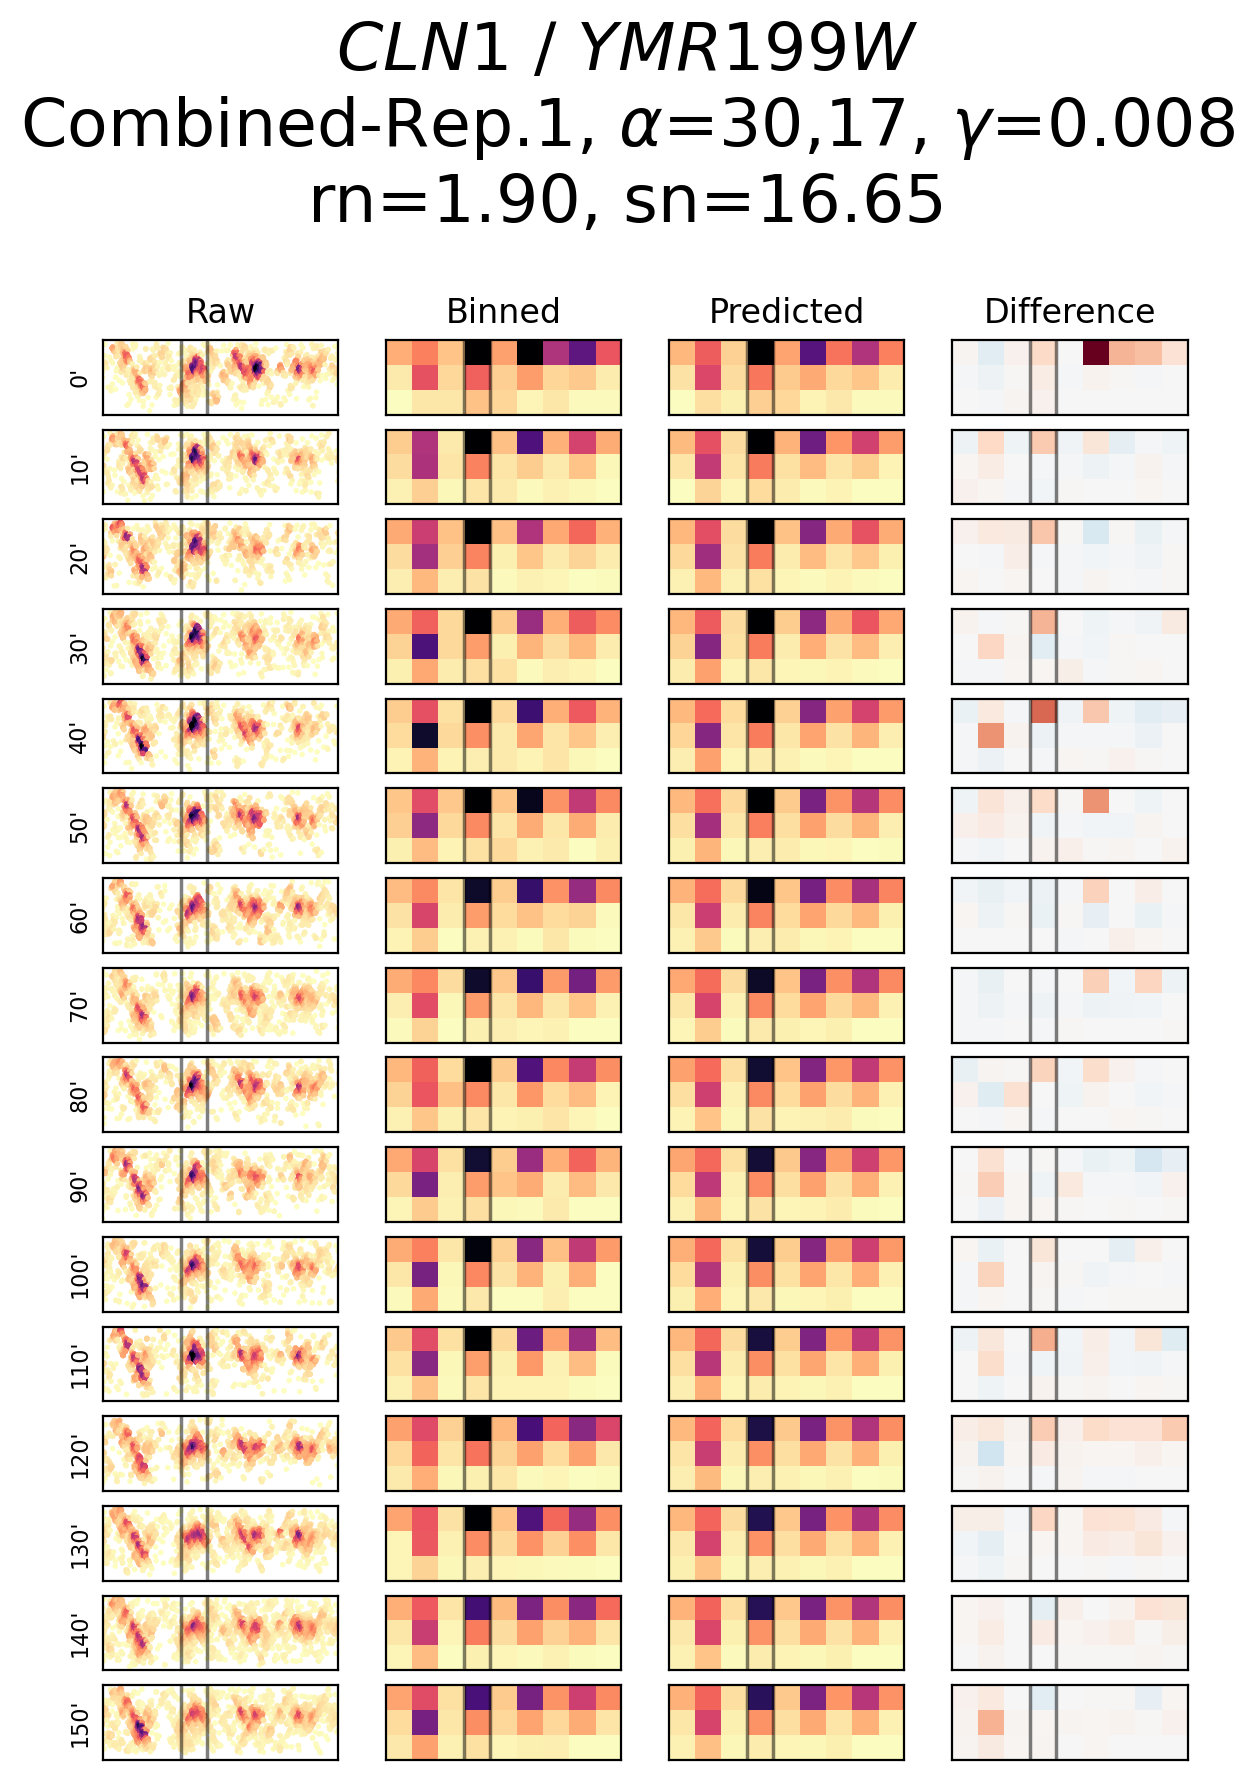

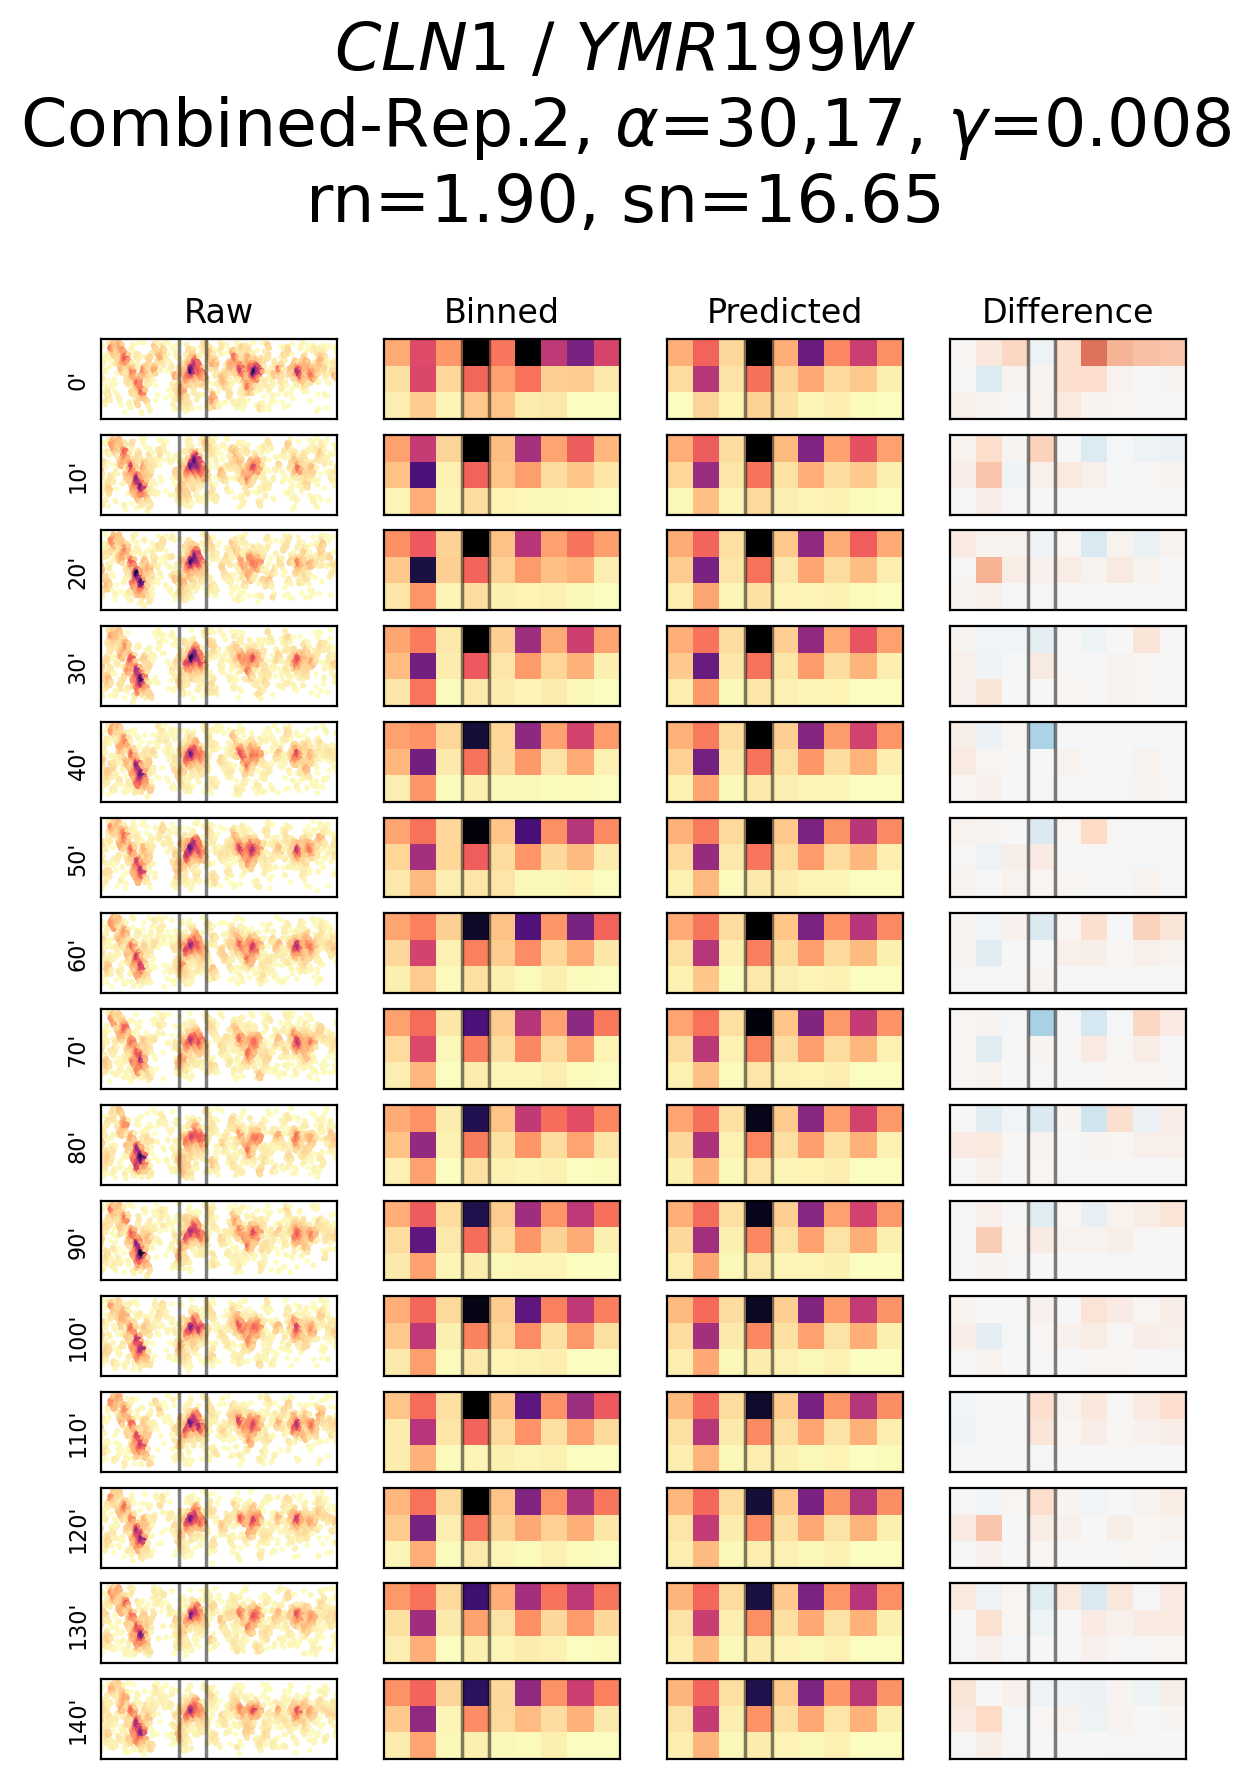

In [24]:
combined_model = deconvolve_gene('CLN1')

Deconvolving CLN2, combined model
Deconvolving gene expression...Done.
Deconvolving chromatin...Loading MNase reads for CLN2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (16, 27)
Loading MNase reads for CLN2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (15, 27)
Applying normalization using scaling matrix: output/mnase/rep2_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (15, 27)
Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 1.2352
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 1.3152, rate = 6.5
  ...   gm = 0.0050, rn = 1.4573, rate = 17.98, time = 00:00:38.

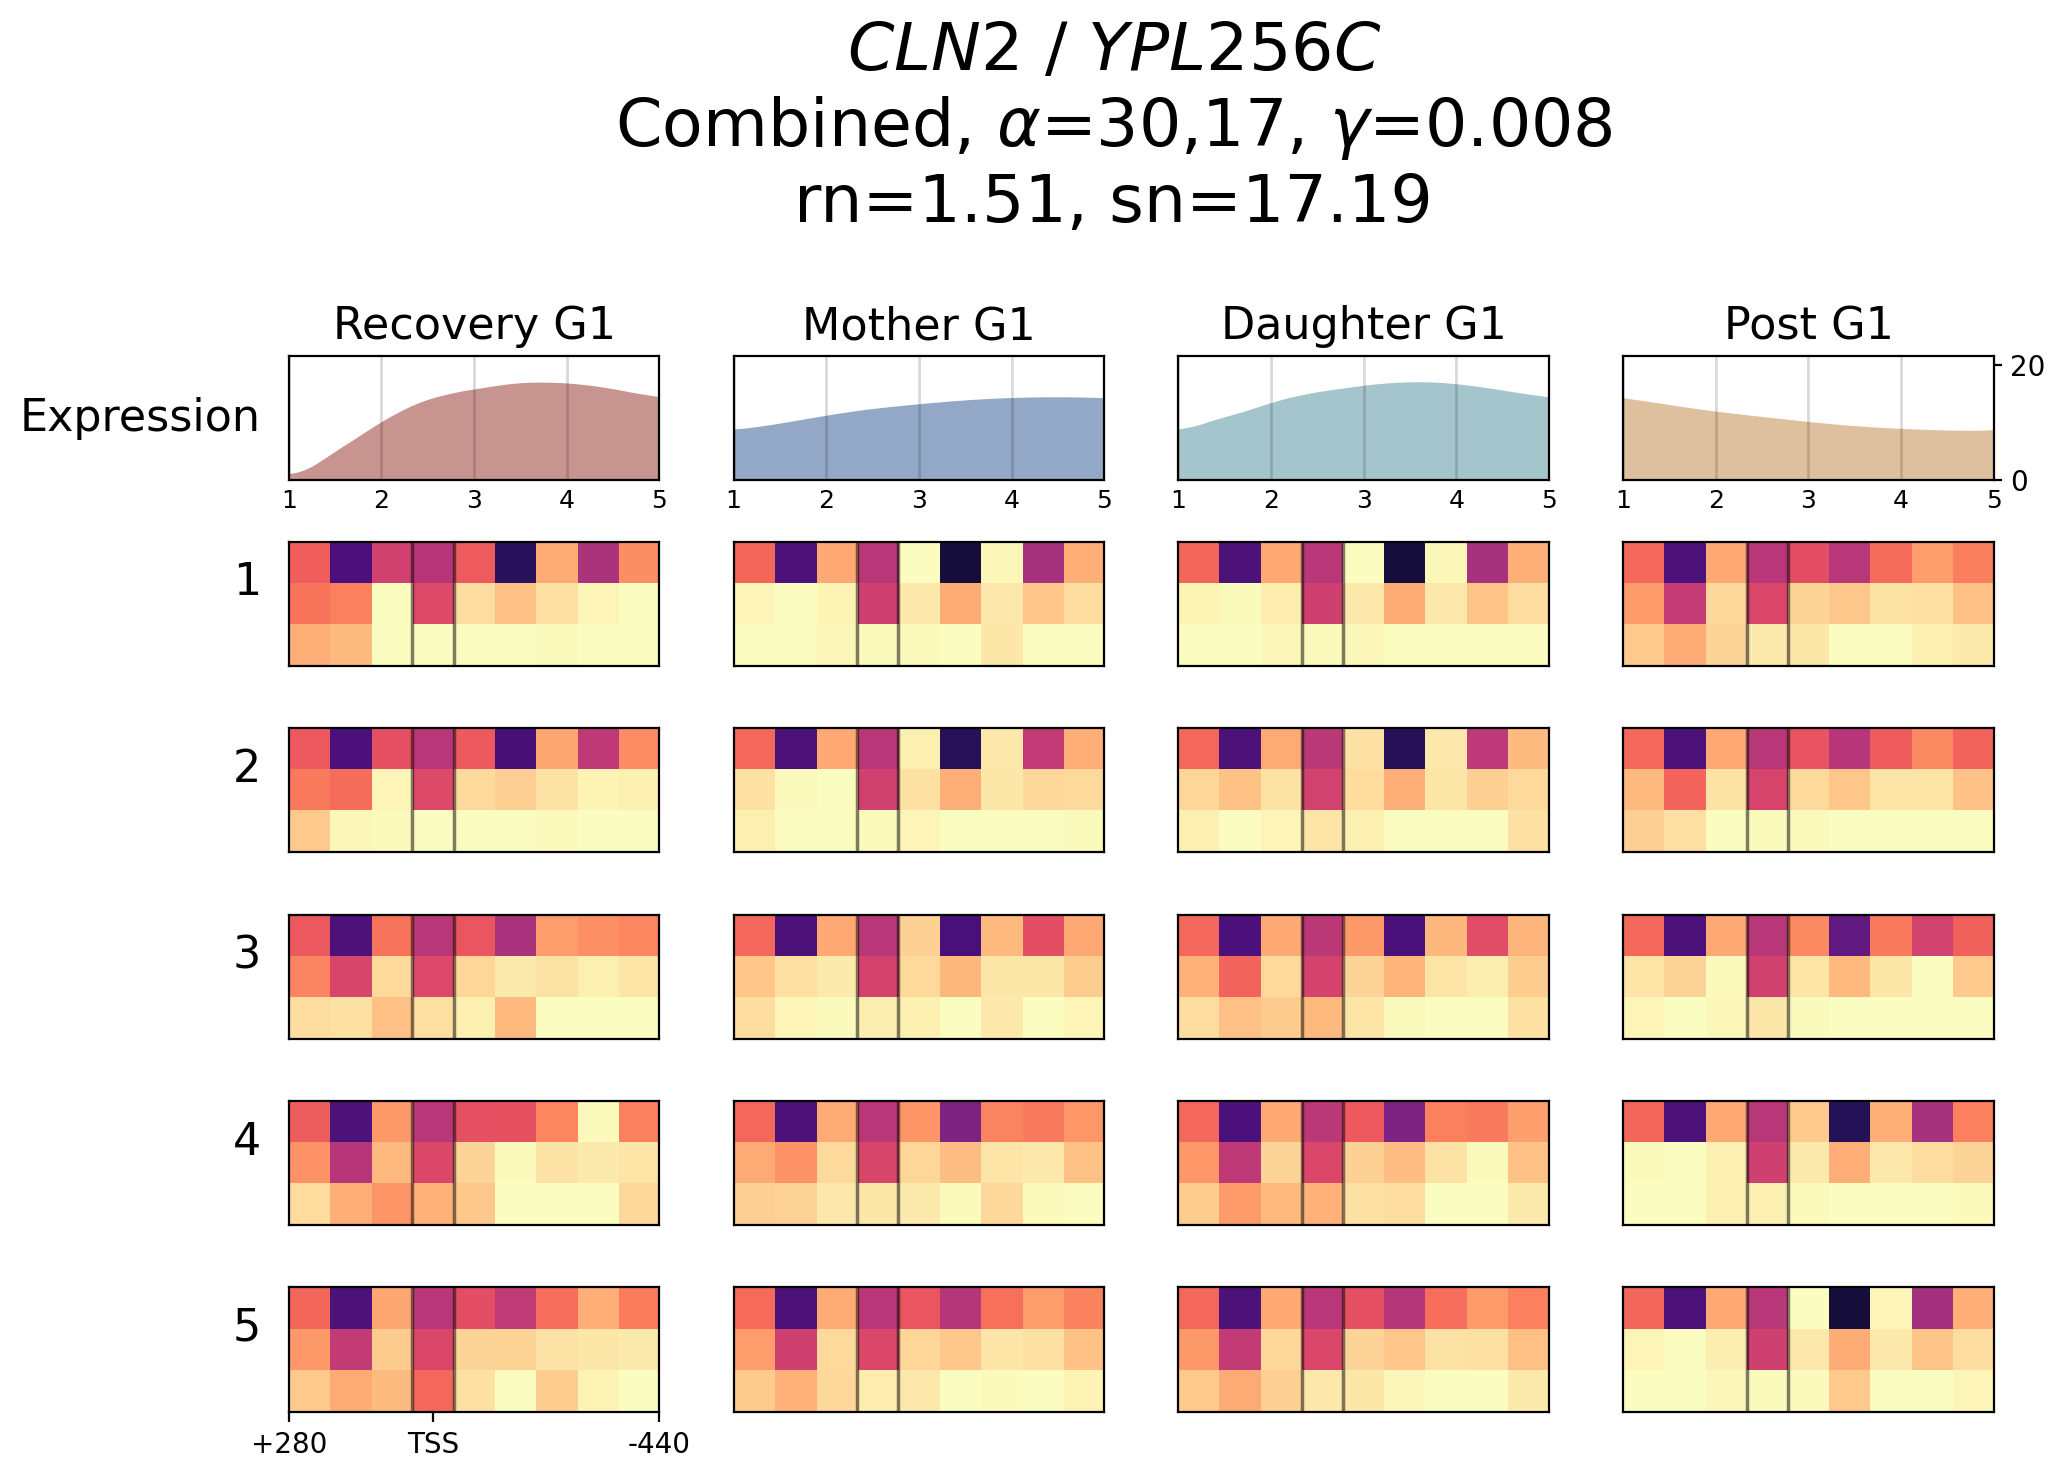

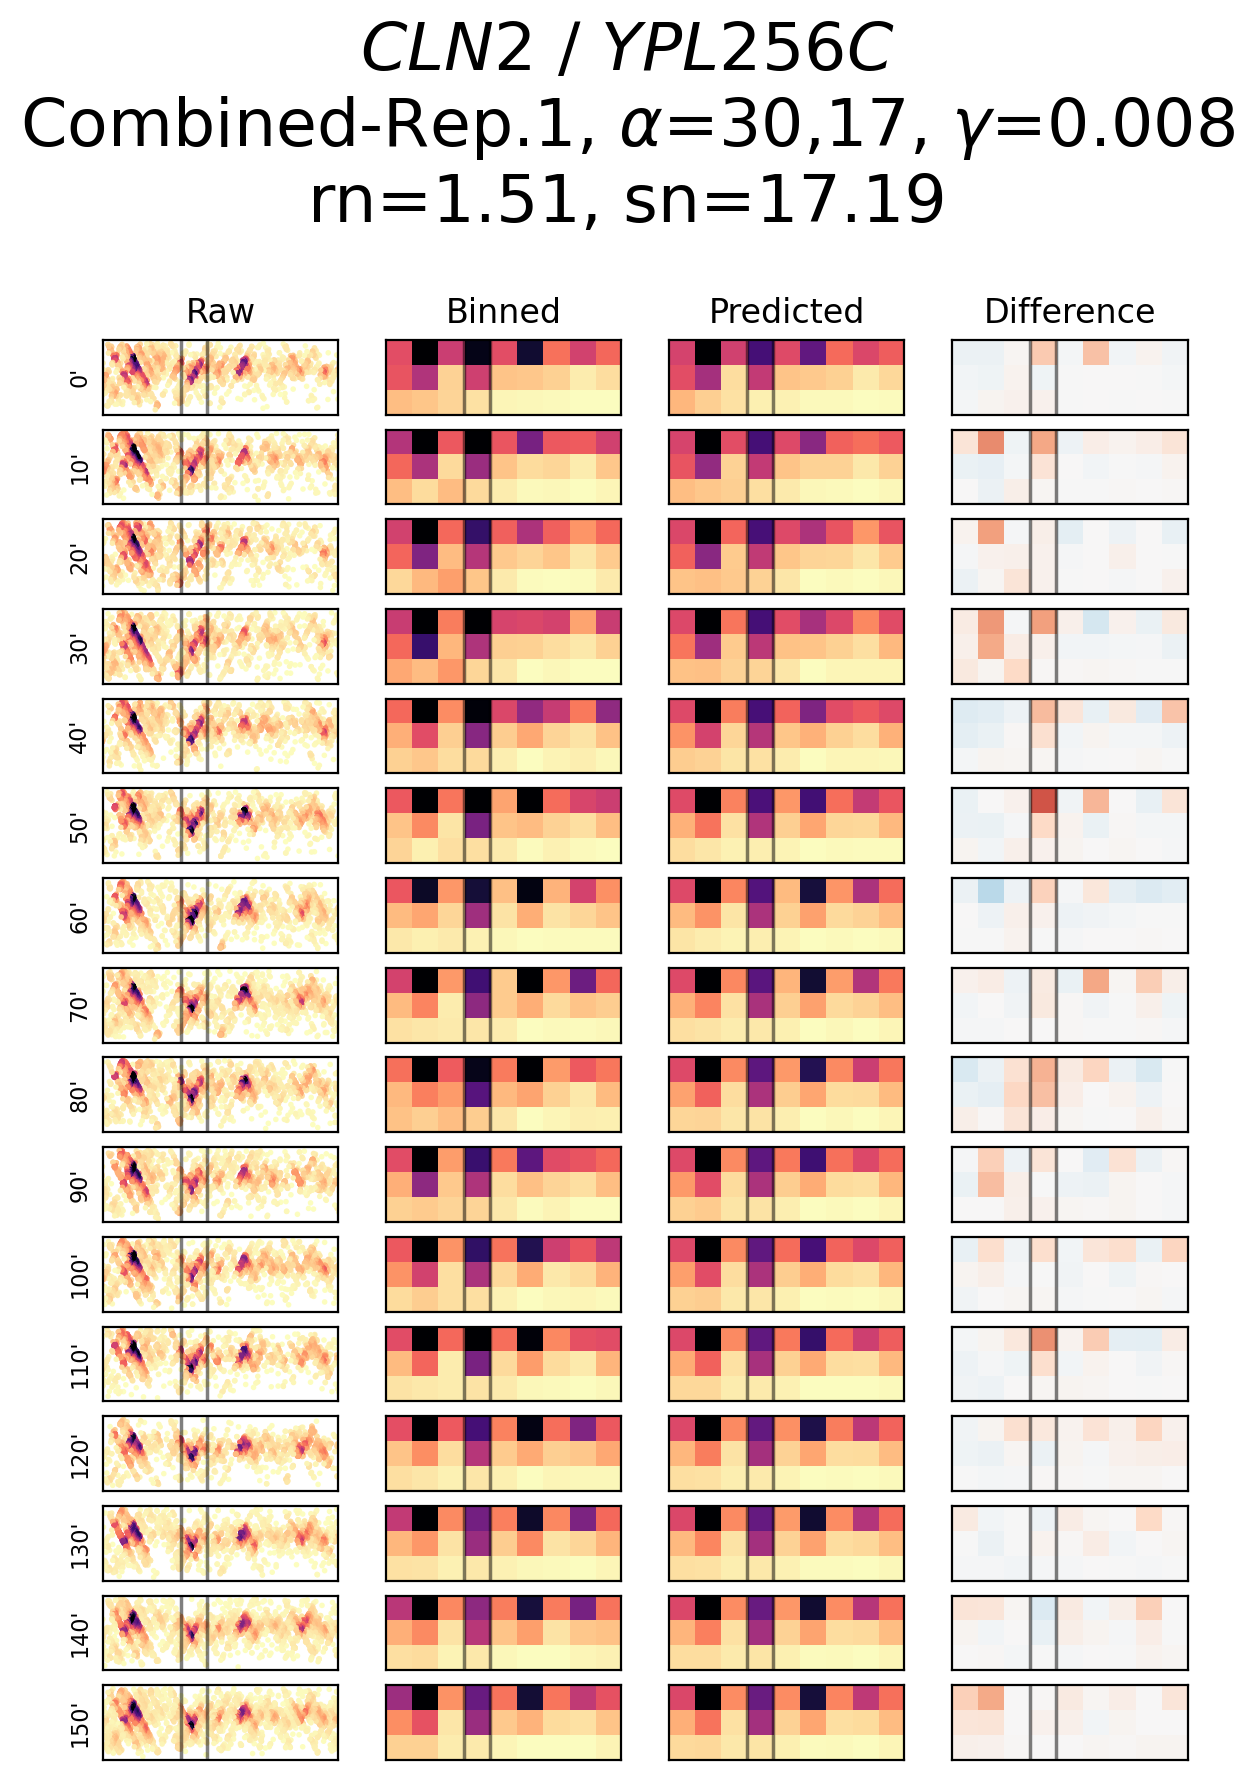

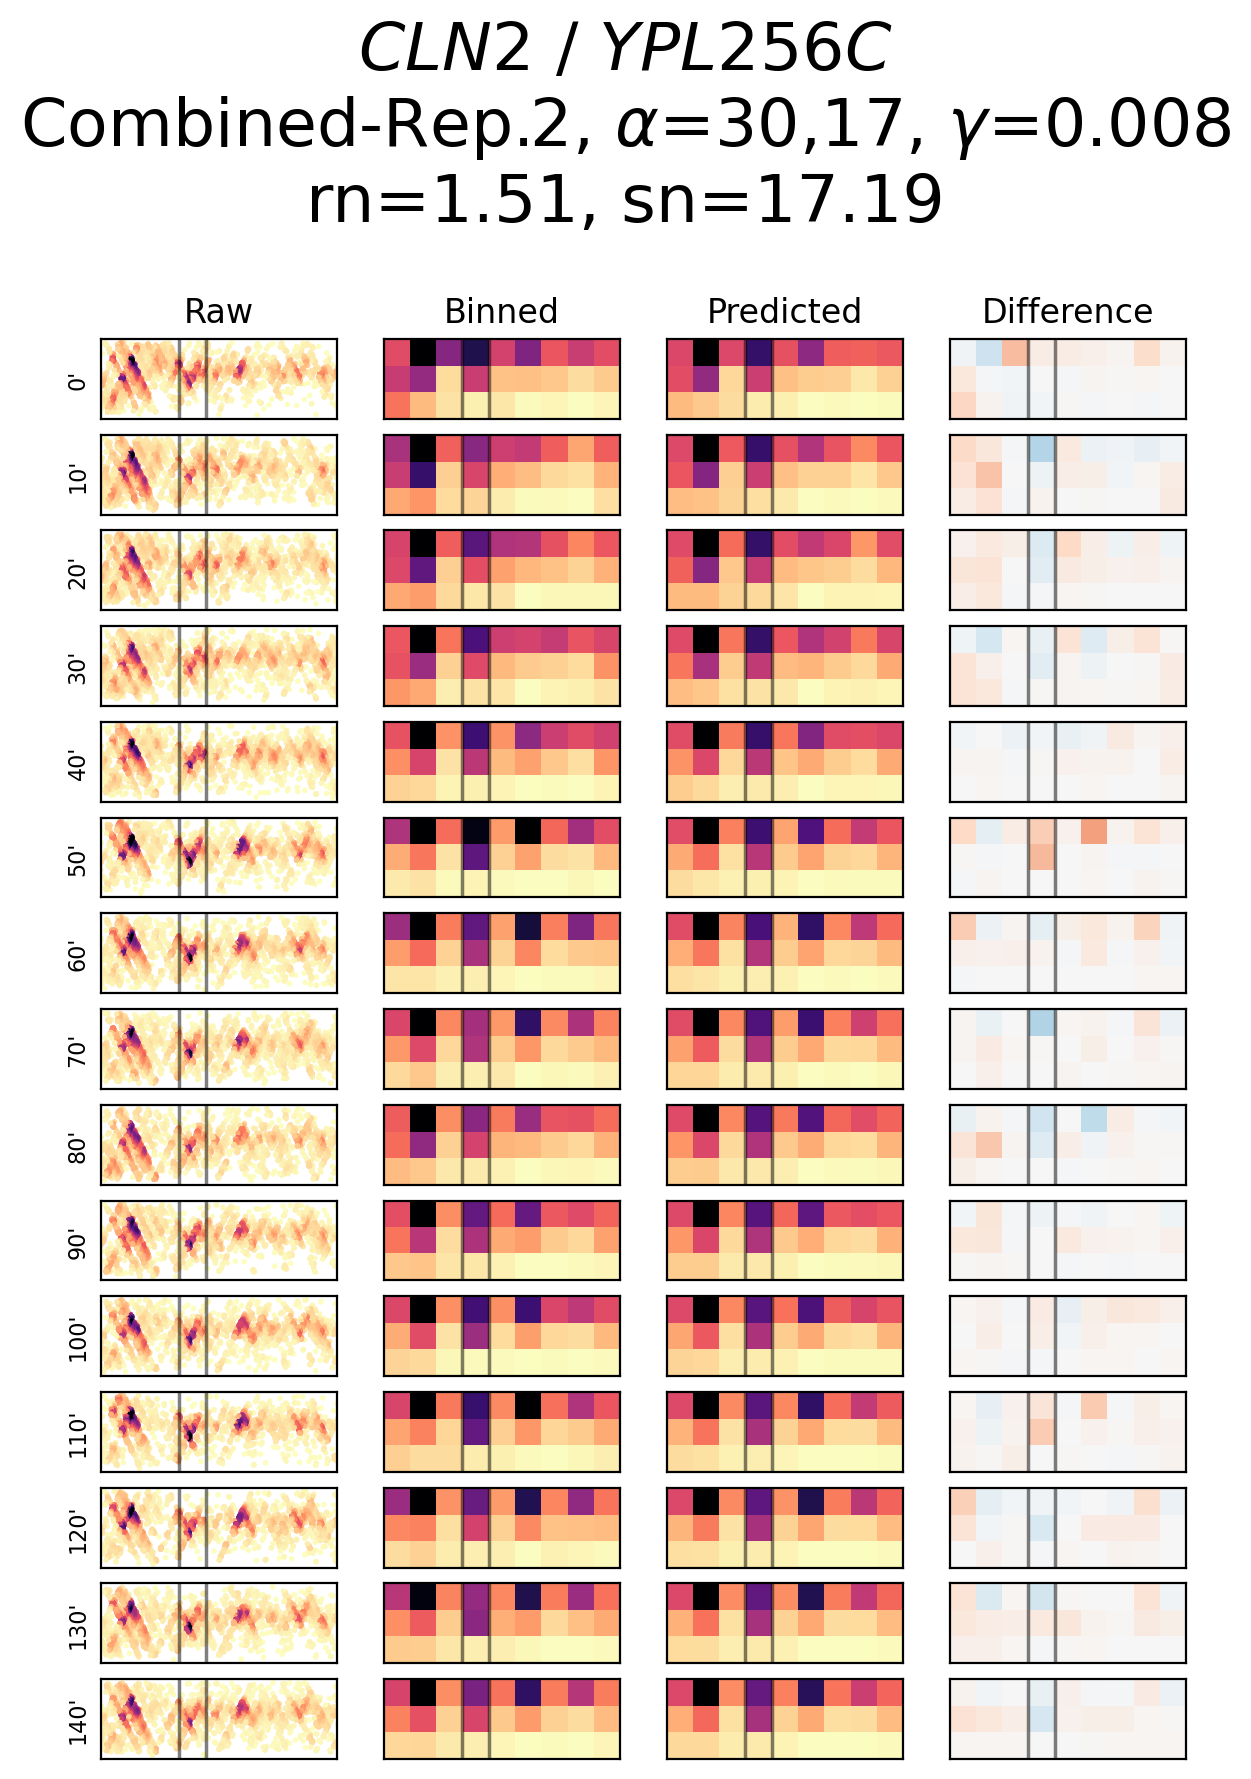

In [23]:
combined_model = deconvolve_gene('CLN2')